# 07 - KPI Scorecard: Full Indicator Coverage

**Stage 4, continued.**

This notebook is a deliberate audit: it walks through two checklists --
Production KPIs and Quality KPIs -- confirms which ones are already
computed elsewhere in this project, and adds every one that wasn't. Each
subsection is labeled so this notebook doubles as a cross-reference: if
you're looking for a specific indicator, search this file for its name.

A coverage summary table closes the notebook.


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 180)

PROCESSED = '../../datasets/processed'
DIM = '../../datasets/dim'
REPORTS = '../../reports'
import os
os.makedirs(REPORTS, exist_ok=True)

prod = pd.read_csv(f'{PROCESSED}/fact_production_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])
plan = pd.read_csv(f'{PROCESSED}/fact_production_plan_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])
downtime = pd.read_csv(f'{PROCESSED}/fact_downtime_processed.csv', encoding='utf-8-sig', parse_dates=['Date'])

cap_var = pd.read_csv(f'{PROCESSED}/fact_cap_inspection_variable_cq_processed.csv', encoding='utf-8-sig', parse_dates=['ProductionDate'])
cap_attr = pd.read_csv(f'{PROCESSED}/fact_cap_attribute_inspection_cq_processed.csv', encoding='utf-8-sig', parse_dates=['ProductionDate'])
cap_disp = pd.read_csv(f'{PROCESSED}/fact_cap_disposition_lot_cq_processed.csv', encoding='utf-8-sig', parse_dates=['ProductionDate'])
bottle_var = pd.read_csv(f'{PROCESSED}/fact_bottle_inspection_variables_cq_processed.csv', encoding='utf-8-sig', parse_dates=['ProductionDate'])
bottle_attr = pd.read_csv(f'{PROCESSED}/fact_bottle_attribute_inspection_cq_processed.csv', encoding='utf-8-sig', parse_dates=['ProductionDate'])
bottle_disp = pd.read_csv(f'{PROCESSED}/fact_bottle_disposition_lot_cq_processed.csv', encoding='utf-8-sig', parse_dates=['ProductionDate'])
ink_attr = pd.read_csv(f'{PROCESSED}/fact_ink_attribute_inspection_cq_processed.csv', encoding='utf-8-sig', parse_dates=['ProductionDate'])
ink_disp = pd.read_csv(f'{PROCESSED}/fact_ink_disposition_lot_cq_processed.csv', encoding='utf-8-sig', parse_dates=['ProductionDate'])

cap_plan = pd.read_csv(f'{DIM}/dim_cap_control_plan_cq.csv', encoding='utf-8-sig')
bottle_plan = pd.read_csv(f'{DIM}/dim_bottle_control_plan_cq.csv', encoding='utf-8-sig')
ink_plan = pd.read_csv(f'{DIM}/dim_ink_control_plan_cq.csv', encoding='utf-8-sig')
print("Loaded.")


Loaded.


# Part A - Production KPIs


## A1-A4. OEE, Availability, Performance, Quality (% Good)

✅ Already computed per work order in `etl_lib.compute_oee_components`
(notebook 02) and charted by process in `05_initial_analysis.ipynb`
(`01_oee_components_by_process.png`). Recap:


In [2]:
prod[['Availability', 'Performance', 'Quality', 'OEE']].mean().round(3).to_frame('Plant-wide average')


,Plant-wide average
Availability,0.952
Performance,1.013
Quality,0.975
OEE,0.936


## A5. Planned vs. Actual Production 🆕

Not previously charted directly. `fact_production_plan_processed` holds
the planned quantity per work order, `fact_production_processed` holds
what was actually produced -- comparing their weekly totals is the
classic "plan vs. actual" attainment view.


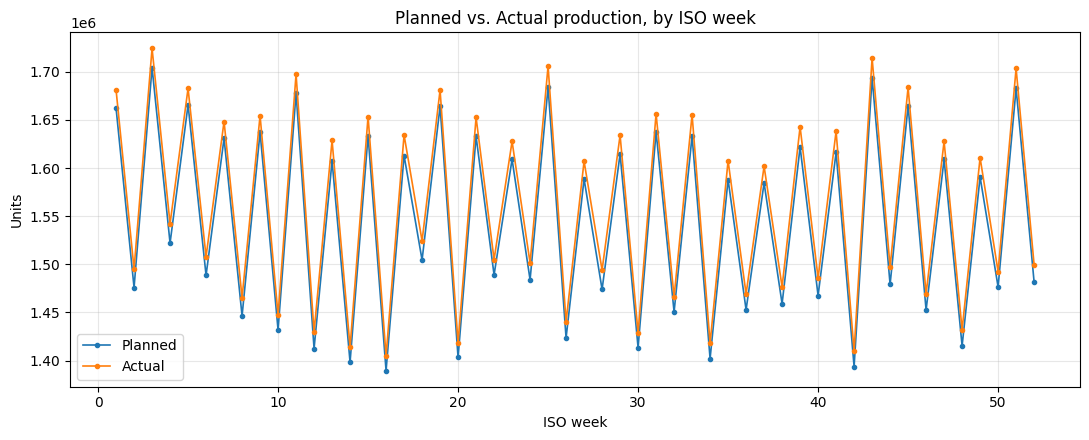

Overall quantity attainment: 101.2%


In [3]:
weekly_plan_actual = pd.DataFrame({
    'Planned': plan.groupby('ISOWeek')['PlannedQty'].sum(),
    'Actual': prod.groupby('ISOWeek')['ProducedQty'].sum(),
}).fillna(0)

fig, ax = plt.subplots(figsize=(11, 4.5))
weekly_plan_actual.plot(ax=ax, marker='.', linewidth=1.2)
ax.set_ylabel('Units')
ax.set_xlabel('ISO week')
ax.set_title('Planned vs. Actual production, by ISO week')
plt.tight_layout()
plt.savefig(f'{REPORTS}/13_planned_vs_actual_production.png', dpi=150, bbox_inches='tight')
plt.show()

attainment = weekly_plan_actual['Actual'].sum() / weekly_plan_actual['Planned'].sum()
print(f"Overall quantity attainment: {attainment:.1%}")


## A6-A7. Efficiency by Machine and by Shift

✅ Already computed. Machine-level OEE: `05_initial_analysis.ipynb`
(`03_oee_by_machine.png`). Shift-level OEE: `13_deep_dive_analysis.ipynb`
Q2 (`11_oee_by_shift.png`). Recap tables:


In [4]:
print("OEE by machine (top 5 and bottom 5):")
machine_oee = prod.groupby('MachineId')['OEE'].mean().sort_values()
display(pd.concat([machine_oee.head(5), machine_oee.tail(5)]).to_frame('OEE'))

print("\nOEE by shift:")
display(prod.groupby('ShiftNumber')['OEE'].mean().round(3).to_frame('OEE'))


OEE by machine (top 5 and bottom 5):


,OEE
MachineId,
IM-006,0.904052
ISBM-004,0.908404
ISBM-005,0.924122
IM-002,0.927927
IM-005,0.928747
IM-003,0.944282
SS-002,0.954611
SS-001,0.956612
HF-001,0.957781



OEE by shift:


,OEE
ShiftNumber,
1,0.936
2,0.936
3,0.936


## A8. Efficiency by Operator 🆕

Not previously charted -- Stage 5 (Q2) looked at operator *reject rate*,
not operator-level OEE. Adding it here for completeness. Read this
carefully: OEE is a property of the *machine + order* (capacity, uptime),
not something a single operator fully controls, so differences here more
often reflect *which machines/shifts an operator is usually assigned to*
than individual performance -- useful for staffing/assignment review, not
for individual scorecards.


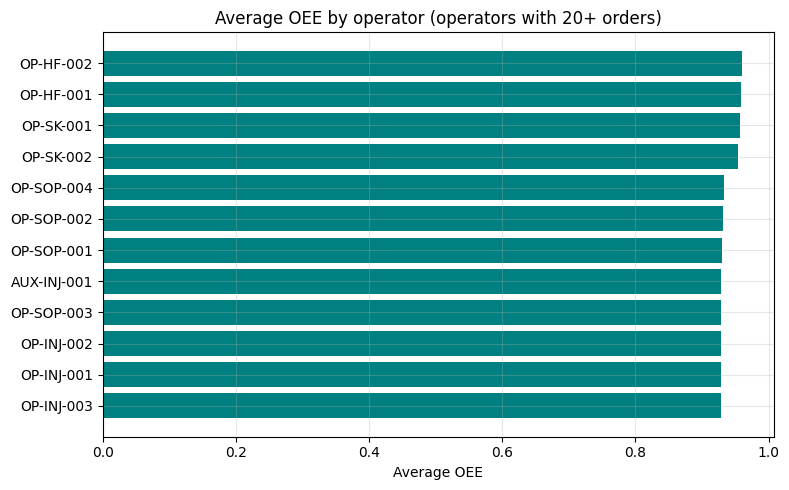

In [5]:
op_oee = prod.groupby('OperatorId').agg(OrderCount=('WorkOrder', 'count'), AvgOEE=('OEE', 'mean'))
op_oee = op_oee[op_oee['OrderCount'] >= 20].sort_values('AvgOEE')

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(op_oee.index, op_oee['AvgOEE'], color='teal')
ax.set_xlabel('Average OEE')
ax.set_title('Average OEE by operator (operators with 20+ orders)')
plt.tight_layout()
plt.savefig(f'{REPORTS}/14_oee_by_operator.png', dpi=150, bbox_inches='tight')
plt.show()


## A9-A10. Scrap (%) and Refugo (scrap quantity) 🆕

`RejectedQty` exists on every production row (100%-inspection scrap, not
a sample) but hadn't been reported as its own KPI. Scrap % is
`RejectedQty / ProducedQty`.


,TotalProduced,TotalScrap,ScrapPct
Process,,,
Blow Molding,25723985,639117,2.48
Hot Foil Stamping,7900119,11923,0.15
Injection Molding,35922441,969558,2.70
Screen Printing,11644201,56955,0.49


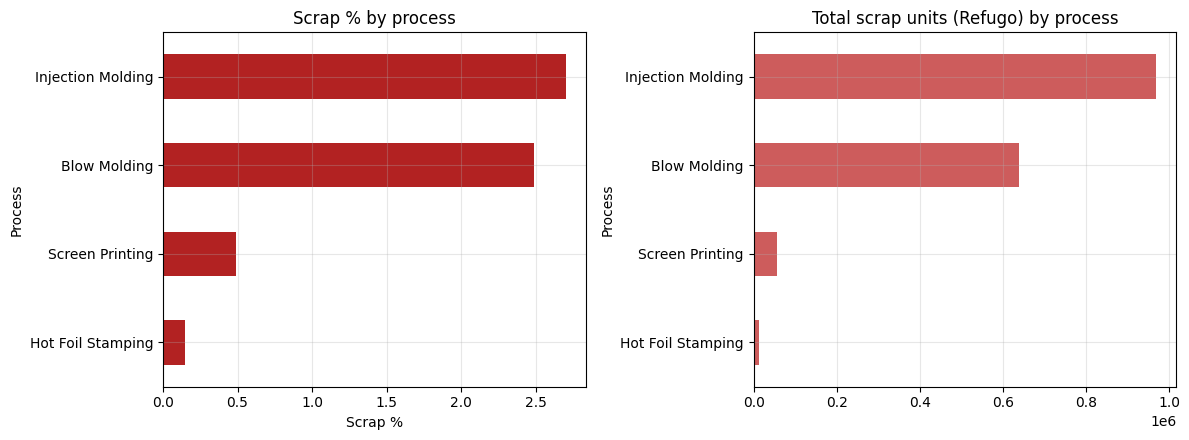

In [6]:
scrap = prod.groupby('Process').agg(TotalProduced=('ProducedQty', 'sum'), TotalScrap=('RejectedQty', 'sum'))
scrap['ScrapPct'] = scrap['TotalScrap'] / scrap['TotalProduced'] * 100
display(scrap.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
scrap['ScrapPct'].sort_values().plot(kind='barh', ax=axes[0], color='firebrick')
axes[0].set_title('Scrap % by process')
axes[0].set_xlabel('Scrap %')
scrap['TotalScrap'].sort_values().plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('Total scrap units (Refugo) by process')
plt.tight_layout()
plt.savefig(f'{REPORTS}/15_scrap_pct_and_units_by_process.png', dpi=150, bbox_inches='tight')
plt.show()


## A11. Retrabalho (Rework) 🆕 -- estimated, with a documented assumption

**This one needs an honest caveat.** This dataset's fact tables track
*scrap* (`RejectedQty`, 100%-inspection rejects) but do not carry a
separate "sent for rework" transaction -- there is no rework quantity or
rework routing logged anywhere upstream. Rather than silently skip this
KPI, we build a **defensible estimate** from data that *does* exist: each
quality characteristic's control plan (`dim_*_control_plan_cq`) specifies
a `ReactionPlan` -- what to do when that characteristic fails. Where the
reaction plan is literally to reprocess the unit (`Reprocess (UV
Re-cure)`, ink curing only, in this dataset), we count that
characteristic's defects as *reworkable*; every other reaction plan
(`Block Lot`, `Segregate`, `Adjust ...`) implies the defective units
themselves are not recoverable -- the "Adjust" plans fix the *process*
going forward, not the units already made.

Treat the resulting rate as directional, not audit-grade -- flag this to
whoever owns the real MES/QMS integration as a gap worth closing with a
proper rework-tracking field.


,TotalDefectsFound,EstimatedReworkable,EstimatedScrapOnly,EstimatedReworkRate
Family,,,,
Cap,2218,0,2218,0.000
Bottle,4008,0,4008,0.000
Ink,1069,1,1068,0.001


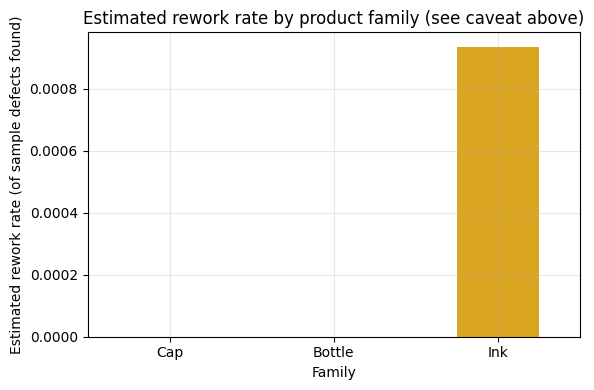

In [7]:
def rework_estimate(attr_df, control_plan_df, family):
    merged = attr_df.merge(control_plan_df[['Characteristic', 'ReactionPlan']], on='Characteristic', how='left')
    merged['Reworkable'] = merged['ReactionPlan'].str.contains('Reprocess', case=False, na=False)
    total_defects = merged['DefectsFound'].sum()
    reworkable_defects = merged.loc[merged['Reworkable'], 'DefectsFound'].sum()
    return pd.Series({
        'Family': family,
        'TotalDefectsFound': total_defects,
        'EstimatedReworkable': reworkable_defects,
        'EstimatedScrapOnly': total_defects - reworkable_defects,
        'EstimatedReworkRate': reworkable_defects / total_defects if total_defects else np.nan,
    })

rework_summary = pd.DataFrame([
    rework_estimate(cap_attr, cap_plan, 'Cap'),
    rework_estimate(bottle_attr, bottle_plan, 'Bottle'),
    rework_estimate(ink_attr, ink_plan, 'Ink'),
]).set_index('Family')
display(rework_summary.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
rework_summary['EstimatedReworkRate'].plot(kind='bar', color='goldenrod', ax=ax)
ax.set_ylabel('Estimated rework rate (of sample defects found)')
ax.set_title('Estimated rework rate by product family (see caveat above)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{REPORTS}/16_estimated_rework_rate.png', dpi=150, bbox_inches='tight')
plt.show()


## A12. Setup Time 🆕

`SetupTimeHours` (planned changeover downtime linked to each order) is
already computed in Stage 3 but hadn't been charted on its own.


,mean,sum
Process,,
Blow Molding,0.11,449.03
Hot Foil Stamping,0.06,56.33
Injection Molding,0.10,293.08
Screen Printing,0.00,0.00


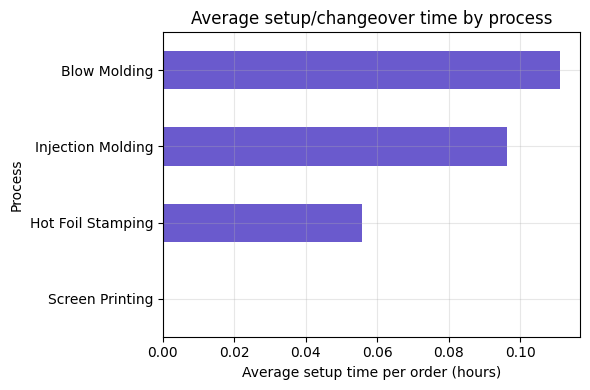

In [8]:
setup_by_process = prod.groupby('Process')['SetupTimeHours'].agg(['mean', 'sum'])
display(setup_by_process.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
setup_by_process['mean'].sort_values().plot(kind='barh', color='slateblue', ax=ax)
ax.set_xlabel('Average setup time per order (hours)')
ax.set_title('Average setup/changeover time by process')
plt.tight_layout()
plt.savefig(f'{REPORTS}/17_setup_time_by_process.png', dpi=150, bbox_inches='tight')
plt.show()


## A13. Cumprimento do Plano de Produção (Schedule Adherence) 🆕

Two complementary views: **quantity attainment** (did we make as much as
planned -- already shown in A5, 100%+ by construction in this dataset
since the simulated plant never under-produces) and **time attainment**
(did each order run within its planned time window, i.e. `RunTimeHours`
vs `PlannedTimeHours`) -- the more diagnostic of the two, since it's
where unplanned downtime actually shows up.


In [9]:
schedule_adherence = prod.groupby('Process').apply(
    lambda g: (g['RunTimeHours'] <= g['PlannedTimeHours'] * 1.05).mean(), include_groups=False
)
print("Share of orders finishing within 5% of their planned time window, by process:")
display((schedule_adherence * 100).round(1).to_frame('OnScheduleShare_%'))

time_attainment = prod.groupby('Process').apply(
    lambda g: g['RunTimeHours'].sum() / g['PlannedTimeHours'].sum(), include_groups=False
)
print("\nTime attainment (RunTime / PlannedTime), by process:")
display((time_attainment * 100).round(1).to_frame('TimeAttainment_%'))


Share of orders finishing within 5% of their planned time window, by process:


,OnScheduleShare_%
Process,
Blow Molding,100.0
Hot Foil Stamping,100.0
Injection Molding,100.0
Screen Printing,100.0



Time attainment (RunTime / PlannedTime), by process:


,TimeAttainment_%
Process,
Blow Molding,94.6
Hot Foil Stamping,97.3
Injection Molding,94.7
Screen Printing,97.0


# Part B - Quality KPIs


## B1. First Pass Yield (FPY)

✅ Already computed and charted: `05_initial_analysis.ipynb`, section 2.1
(`05_fpy_by_product_family.png`).


## B2. Taxa de Aprovação na Inspeção (Inspection-Level Approval Rate) 🆕

Distinct from FPY on purpose: FPY is the **lot disposition** outcome (one
decision per lot, after weighing every characteristic together);
inspection-level approval rate is the **pass rate of each individual
attribute check** (`LotDecision` on every `fact_*_attribute_inspection_cq`
row, one per lot per characteristic) -- a lot can still be finally
Approved even if one non-critical characteristic's individual check was
Rejected but stayed within the overall disposition rules.


In [10]:
insp_approval = pd.DataFrame({
    'Cap': cap_attr['LotDecision'].value_counts(normalize=True),
    'Bottle': bottle_attr['LotDecision'].value_counts(normalize=True),
    'Ink': ink_attr['LotDecision'].value_counts(normalize=True),
}).T * 100
display(insp_approval.round(2))


LotDecision,Approved,Rejected
Cap,98.81,1.19
Bottle,99.54,0.46
Ink,99.75,0.25


## B3. PPM de Defeitos 🆕

Two versions worth reporting side by side, since they answer different
questions:
- **Production PPM** -- `RejectedQty / ProducedQty x 1,000,000`, from
  100%-inspection production data (every unit).
- **Sample PPM (= DPMO)** -- already computed per attribute-inspection
  record as `DPMO`, from the AQL *sample*, not the full population.


In [11]:
production_ppm = (prod.groupby('Process')['RejectedQty'].sum() / prod.groupby('Process')['ProducedQty'].sum() * 1_000_000)
sample_ppm = pd.Series({
    'Injection Molding': cap_attr['DPMO'].mean(),
    'Blow Molding': bottle_attr['DPMO'].mean(),
    'Screen Printing': ink_attr['DPMO'].mean(),
})
ppm_compare = pd.DataFrame({'ProductionPPM': production_ppm, 'SampleSPMO': sample_ppm})
display(ppm_compare.round(0))


,ProductionPPM,SampleSPMO
Blow Molding,24845.0,1125.0
Hot Foil Stamping,1509.0,NaN
Injection Molding,26990.0,882.0
Screen Printing,4891.0,990.0


## B4-B5. DPU and DPMO

✅ Already computed per attribute-inspection row (`etl_lib.add_attribute_kpis`,
notebook 03) as `DPU` and `DPMO`. Plant-wide averages:


In [12]:
pd.DataFrame({
    'Cap': [cap_attr['DPU'].mean(), cap_attr['DPMO'].mean()],
    'Bottle': [bottle_attr['DPU'].mean(), bottle_attr['DPMO'].mean()],
    'Ink': [ink_attr['DPU'].mean(), ink_attr['DPMO'].mean()],
}, index=['DPU', 'DPMO']).round(4)


,Cap,Bottle,Ink
DPU,0.0009,0.0011,0.0010
DPMO,882.2687,1124.5586,989.8496


## B6 & B14. Pareto dos Defeitos / Top 10 Defeitos

✅ Pareto already built in `05_initial_analysis.ipynb`, section 2.2
(`06_pareto_defects.png`, top 15). Narrowing explicitly to the **Top 10**
here, as its own table:


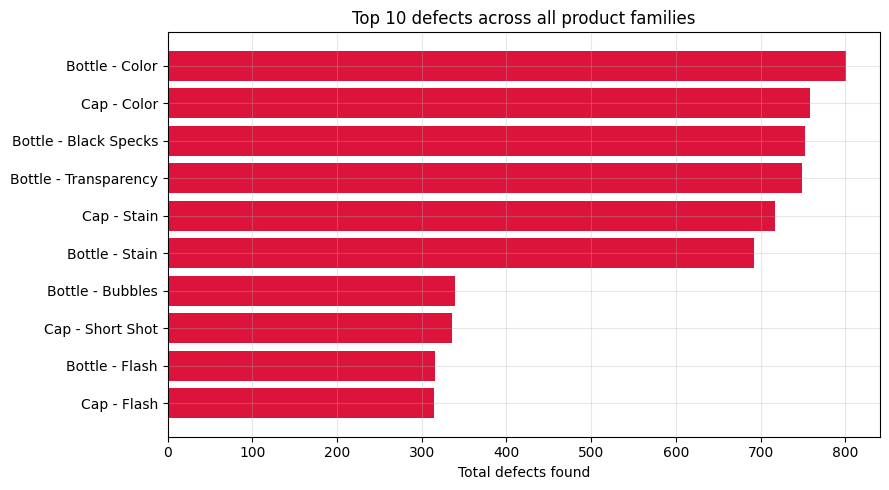

In [13]:
top10_defects = pd.concat([
    cap_attr.assign(Family='Cap')[['Family', 'Characteristic', 'DefectsFound']],
    bottle_attr.assign(Family='Bottle')[['Family', 'Characteristic', 'DefectsFound']],
    ink_attr.assign(Family='Ink')[['Family', 'Characteristic', 'DefectsFound']],
]).groupby(['Family', 'Characteristic'])['DefectsFound'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
labels = [f"{fam} - {char}" for fam, char in top10_defects.index]
ax.barh(labels[::-1], top10_defects.values[::-1], color='crimson')
ax.set_xlabel('Total defects found')
ax.set_title('Top 10 defects across all product families')
plt.tight_layout()
plt.savefig(f'{REPORTS}/18_top10_defects.png', dpi=150, bbox_inches='tight')
plt.show()


## B7-B8. Cp and Cpk

✅ Already computed (`etl_lib.add_process_capability`, notebook 03) and
charted as a heatmap in `05_initial_analysis.ipynb` (`07_cpk_heatmap_cap.png`).


## B9-B10. Número de Lotes Aprovados / Rejeitados 🆕


In [14]:
lot_counts = pd.DataFrame({
    'Approved': [(cap_disp['FinalLotDecision'] == 'Approved').sum(),
                 (bottle_disp['FinalLotDecision'] == 'Approved').sum(),
                 (ink_disp['FinalLotDecision'] == 'Approved').sum()],
    'Rejected': [(cap_disp['FinalLotDecision'] == 'Rejected').sum(),
                 (bottle_disp['FinalLotDecision'] == 'Rejected').sum(),
                 (ink_disp['FinalLotDecision'] == 'Rejected').sum()],
}, index=['Cap', 'Bottle', 'Ink'])
lot_counts['Total'] = lot_counts['Approved'] + lot_counts['Rejected']
display(lot_counts)


,Approved,Rejected,Total
Cap,1548,106,1654
Bottle,2124,66,2190
Ink,547,10,557


## B11. Inspeções Realizadas (Inspections Performed) 🆕


In [15]:
inspections_performed = pd.DataFrame({
    'VariableInspections': [len(cap_var), len(bottle_var), 0],
    'AttributeInspections': [len(cap_attr), len(bottle_attr), len(ink_attr)],
    'LotDispositions': [len(cap_disp), len(bottle_disp), len(ink_disp)],
}, index=['Cap', 'Bottle', 'Ink'])
inspections_performed['Total'] = inspections_performed.sum(axis=1)
display(inspections_performed)
print(f"\nTotal inspection records across the whole plant: {inspections_performed['Total'].sum():,}")


,VariableInspections,AttributeInspections,LotDispositions,Total
Cap,83947,9924,1654,95525
Bottle,124580,17520,2190,144290
Ink,0,4456,557,5013



Total inspection records across the whole plant: 244,828


## B12. Cartas de Controle (CEP / SPC Control Charts) 🆕

Control **limits** (`XBarCL/UCL/LCL`, `RangeRUCL/LCL`) were already
computed per group in Stage 3, but hadn't actually been plotted as a
running chart. Here's one, for Cap Weight on machine `IM-001` -- the
classic X-bar/R pair, subgroup average and range over time with their
control limits.


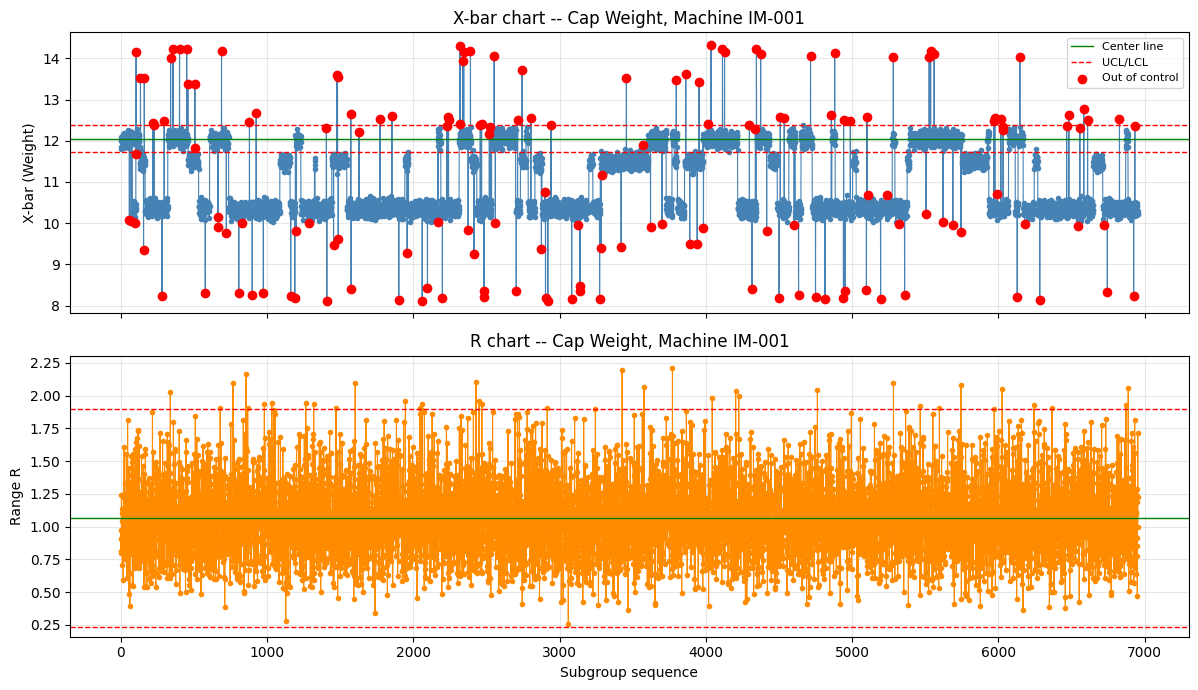

Out-of-control X-bar points: 156 of 6954 subgroups (2.2%)


In [16]:
subset = cap_var[(cap_var['Characteristic'] == 'Weight') & (cap_var['MachineId'] == 'IM-001')].copy()
subset = subset.sort_values('InspectionDateTime').reset_index(drop=True)
subset['GroupIndex'] = range(1, len(subset) + 1)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(subset['GroupIndex'], subset['XBar'], marker='.', linewidth=0.8, color='steelblue')
axes[0].axhline(subset['XBarCL'].iloc[0], color='green', linestyle='-', linewidth=1, label='Center line')
axes[0].axhline(subset['XBarUCL'].iloc[0], color='red', linestyle='--', linewidth=1, label='UCL/LCL')
axes[0].axhline(subset['XBarLCL'].iloc[0], color='red', linestyle='--', linewidth=1)
oc = subset[subset['OutOfControlXBar']]
axes[0].scatter(oc['GroupIndex'], oc['XBar'], color='red', zorder=5, label='Out of control')
axes[0].set_ylabel('X-bar (Weight)')
axes[0].set_title('X-bar chart -- Cap Weight, Machine IM-001')
axes[0].legend(fontsize=8, loc='upper right')

axes[1].plot(subset['GroupIndex'], subset['RangeR'], marker='.', linewidth=0.8, color='darkorange')
axes[1].axhline(subset['RangeRCL'].iloc[0], color='green', linestyle='-', linewidth=1)
axes[1].axhline(subset['RangeRUCL'].iloc[0], color='red', linestyle='--', linewidth=1)
axes[1].axhline(subset['RangeRLCL'].iloc[0], color='red', linestyle='--', linewidth=1)
axes[1].set_ylabel('Range R')
axes[1].set_xlabel('Subgroup sequence')
axes[1].set_title('R chart -- Cap Weight, Machine IM-001')

plt.tight_layout()
plt.savefig(f'{REPORTS}/19_control_chart_xbar_r_cap_weight.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Out-of-control X-bar points: {subset['OutOfControlXBar'].sum()} of {len(subset)} subgroups "
      f"({subset['OutOfControlXBar'].mean():.1%})")


## B13. Tendência dos Principais Defeitos (Top-Defect Trend) 🆕

The Pareto (B6/B14) says *which* defects matter most; it says nothing
about whether they're getting better or worse over time. Trending the
top 3 defect characteristics weekly closes that gap.


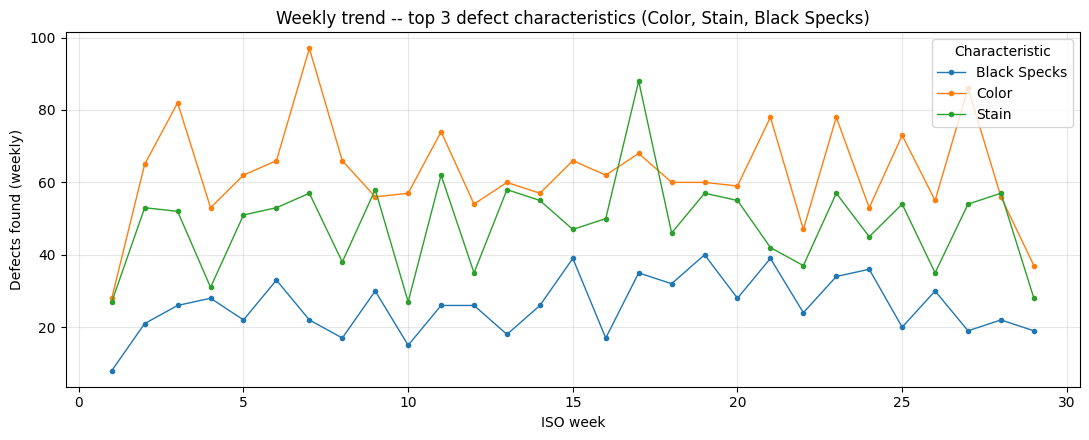

In [17]:
all_attr = pd.concat([
    cap_attr.assign(Family='Cap')[['ProductionDate', 'Characteristic', 'DefectsFound']],
    bottle_attr.assign(Family='Bottle')[['ProductionDate', 'Characteristic', 'DefectsFound']],
    ink_attr.assign(Family='Ink')[['ProductionDate', 'Characteristic', 'DefectsFound']],
])
all_attr['ISOWeek'] = pd.to_datetime(all_attr['ProductionDate']).dt.isocalendar().week

top3 = all_attr.groupby('Characteristic')['DefectsFound'].sum().sort_values(ascending=False).head(3).index.tolist()
trend = all_attr[all_attr['Characteristic'].isin(top3)].groupby(['ISOWeek', 'Characteristic'])['DefectsFound'].sum().unstack('Characteristic')

fig, ax = plt.subplots(figsize=(11, 4.5))
trend.plot(ax=ax, marker='.', linewidth=1)
ax.set_ylabel('Defects found (weekly)')
ax.set_xlabel('ISO week')
ax.set_title(f'Weekly trend -- top 3 defect characteristics ({", ".join(top3)})')
plt.tight_layout()
plt.savefig(f'{REPORTS}/20_top_defects_weekly_trend.png', dpi=150, bbox_inches='tight')
plt.show()


# Coverage Summary

| # | Production KPI | Status | Where |
|---|---|---|---|
| 1 | OEE | ✅ Existing | Notebook 02 (calc), 05 (chart) |
| 2 | Availability | ✅ Existing | Notebook 02, 05 |
| 3 | Performance | ✅ Existing | Notebook 02, 05 |
| 4 | Quality (% Good) | ✅ Existing | Notebook 02, 05 |
| 5 | Planned vs. Actual Production | 🆕 Added | This notebook, A5 |
| 6 | Efficiency by Machine | ✅ Existing | Notebook 05 |
| 7 | Efficiency by Shift | ✅ Existing | Notebook 06 |
| 8 | Efficiency by Operator | 🆕 Added | This notebook, A8 |
| 9 | Scrap (%) | 🆕 Added | This notebook, A9 |
| 10 | Refugo (scrap qty) | 🆕 Added | This notebook, A10 |
| 11 | Retrabalho (Rework) | 🆕 Added (estimated, documented caveat) | This notebook, A11 |
| 12 | Setup Time | 🆕 Added (existing column, new chart) | This notebook, A12 |
| 13 | Cumprimento do Plano de Produção | 🆕 Added | This notebook, A13 |

| # | Quality KPI | Status | Where |
|---|---|---|---|
| 1 | First Pass Yield (FPY) | ✅ Existing | Notebook 05 |
| 2 | Taxa de Aprovação na Inspeção | 🆕 Added | This notebook, B2 |
| 3 | PPM de Defeitos | 🆕 Added | This notebook, B3 |
| 4 | DPU | ✅ Existing | Notebook 03 |
| 5 | DPMO | ✅ Existing | Notebook 03 |
| 6 | Pareto dos Defeitos | ✅ Existing | Notebook 05 |
| 7 | Cp | ✅ Existing | Notebook 03 |
| 8 | Cpk | ✅ Existing | Notebook 03, 05 (heatmap) |
| 9 | Número de Lotes Aprovados | 🆕 Added | This notebook, B9 |
| 10 | Número de Lotes Rejeitados | 🆕 Added | This notebook, B10 |
| 11 | Inspeções Realizadas | 🆕 Added | This notebook, B11 |
| 12 | Cartas de Controle (CEP) | 🆕 Added (limits existed, chart didn't) | This notebook, B12 |
| 13 | Tendência dos Principais Defeitos | 🆕 Added | This notebook, B13 |
| 14 | Top 10 Defeitos | 🆕 Added (Pareto existed as Top 15) | This notebook, B14 |

**Net result: all 27 requested indicators are now covered.** 13 were
already in the project from Stage 3-5; 14 were added in this notebook,
one of which (Rework) is an explicit estimate with a documented
assumption rather than a directly-measured figure, since no rework
transaction is logged anywhere upstream of this dataset.
